In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stat
import seaborn as sns

In [2]:
df = pd.read_csv('global_student_digital_behavior_dataset.csv', index_col= 'student_id')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1 to 500000
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   country                         500000 non-null  object 
 1   development_level               500000 non-null  object 
 2   poverty_rate_percent            500000 non-null  float64
 3   internet_infrastructure_index   500000 non-null  float64
 4   average_internet_speed_mbps     500000 non-null  float64
 5   age                             500000 non-null  int64  
 6   gender                          500000 non-null  object 
 7   urban_rural                     500000 non-null  object 
 8   family_income_level             500000 non-null  object 
 9   device_access                   500000 non-null  object 
 10  internet_access_hours           500000 non-null  float64
 11  education_level                 500000 non-null  object 
 12  field_of_study       

##### Fillin values in columns who have nan values more the 1000

In [3]:
df['brain_rot_level'] = df['brain_rot_level'].fillna('NA')
df['field_of_study'] = df['field_of_study'].fillna('NA')

In [4]:
df.isnull().sum()

country                           0
development_level                 0
poverty_rate_percent              0
internet_infrastructure_index     0
average_internet_speed_mbps       0
age                               0
gender                            0
urban_rural                       0
family_income_level               0
device_access                     0
internet_access_hours             0
education_level                   0
field_of_study                    0
academic_motivation               0
online_learning_hours             0
social_media_hours                0
sessions_per_day                  0
average_session_length_minutes    0
late_night_usage                  0
education_content_hours           0
short_video_hours                 0
entertainment_content_hours       0
news_content_hours                0
likes_given_per_day               0
comments_written_per_day          0
posts_created_per_week            0
late_night_score                  0
brain_rot_index             

mapping ordinal data/ to reduce redundance

In [5]:
brain_map = {'Low':1, 'Moderate':2, 'NA':0}

late_night = {'Sometimes': 2, 'Often': 3, 'Never': 1, 'Always': 4}

yes_no = {'Yes': 1,'No': 0}

df['brain_rot_level'] = df['brain_rot_level'].map(brain_map)
df['late_night_usage'] = df['late_night_usage'].map(late_night)
df['cyberbullying_exposure'] = df['cyberbullying_exposure'].map(yes_no)
df['adult_content_exposure'] = df['adult_content_exposure'].map(yes_no)

converting data into relevent data type for better memory optimization

In [6]:
column_to_category = ["country","development_level","gender",
    "urban_rural","family_income_level",
    "device_access",
    "education_level",
    "field_of_study"]

df[column_to_category]= df[column_to_category].astype('category')

column_to_int8 = df.select_dtypes(include= 'int64').columns.tolist()

df[column_to_int8]= df[column_to_int8].astype('int8')

columns_to_clean = df.select_dtypes(include= 'float64').columns.tolist()

df[columns_to_clean]= df[columns_to_clean].astype('float32')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1 to 500000
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   country                         500000 non-null  category
 1   development_level               500000 non-null  category
 2   poverty_rate_percent            500000 non-null  float32 
 3   internet_infrastructure_index   500000 non-null  float32 
 4   average_internet_speed_mbps     500000 non-null  float32 
 5   age                             500000 non-null  int8    
 6   gender                          500000 non-null  category
 7   urban_rural                     500000 non-null  category
 8   family_income_level             500000 non-null  category
 9   device_access                   500000 non-null  category
 10  internet_access_hours           500000 non-null  float32 
 11  education_level                 500000 non-null  category
 12  field_o

exporting file

In [7]:
data = df.copy()

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 1 to 500000
Data columns (total 47 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   country                         500000 non-null  category
 1   development_level               500000 non-null  category
 2   poverty_rate_percent            500000 non-null  float32 
 3   internet_infrastructure_index   500000 non-null  float32 
 4   average_internet_speed_mbps     500000 non-null  float32 
 5   age                             500000 non-null  int8    
 6   gender                          500000 non-null  category
 7   urban_rural                     500000 non-null  category
 8   family_income_level             500000 non-null  category
 9   device_access                   500000 non-null  category
 10  internet_access_hours           500000 non-null  float32 
 11  education_level                 500000 non-null  category
 12  field_o

In [8]:
data.describe(include= 'all')

,country,development_level,poverty_rate_percent,internet_infrastructure_index,average_internet_speed_mbps,age,gender,urban_rural,family_income_level,device_access,...,ads_viewed_per_day,ads_clicked_per_week,impulse_purchase_score,digital_spending_per_month,cyberbullying_exposure,adult_content_exposure,digital_addiction_score,wellbeing_index,academic_risk_score,financial_risk_score
count,500000,500000,500000.000000,500000.000000,500000.000000,500000.000000,500000,500000,500000,500000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
unique,50,3,NaN,NaN,NaN,NaN,3,2,3,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Cambodia,Developing,NaN,NaN,NaN,NaN,Female,Urban,Middle,Smartphone,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10190,210346,NaN,NaN,NaN,NaN,245241,276864,229618,302885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,26.157520,60.211647,72.663162,19.996474,NaN,NaN,NaN,NaN,...,97.020683,12.643291,5.483062,59.888424,0.123996,0.183750,14.074257,57.259258,0.110863,41.659393
std,NaN,NaN,15.246496,20.732889,65.315300,3.161021,NaN,NaN,NaN,NaN,...,33.335934,4.469668,1.578085,29.120811,0.329577,0.387281,5.916848,10.568436,0.796290,13.584694
min,NaN,NaN,5.210000,20.760000,5.740000,15.000000,NaN,NaN,NaN,NaN,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.755421,0.000000,0.000000
25%,NaN,NaN,13.660000,43.130001,20.420000,17.000000,NaN,NaN,NaN,NaN,...,73.817804,9.557981,4.398106,38.202778,0.000000,0.000000,9.906583,50.058289,0.000000,32.211890
50%,NaN,NaN,22.330000,55.750000,45.630001,20.000000,NaN,NaN,NaN,NaN,...,95.385941,12.492321,5.446927,55.094269,0.000000,0.000000,13.608464,57.444351,0.000000,41.019861
75%,NaN,NaN,37.930000,78.919998,107.410004,23.000000,NaN,NaN,NaN,NaN,...,118.644707,15.577609,6.539470,76.732046,0.000000,0.000000,18.043003,64.640518,0.000000,50.493557


Text(0, 0.5, 'Number of Students')

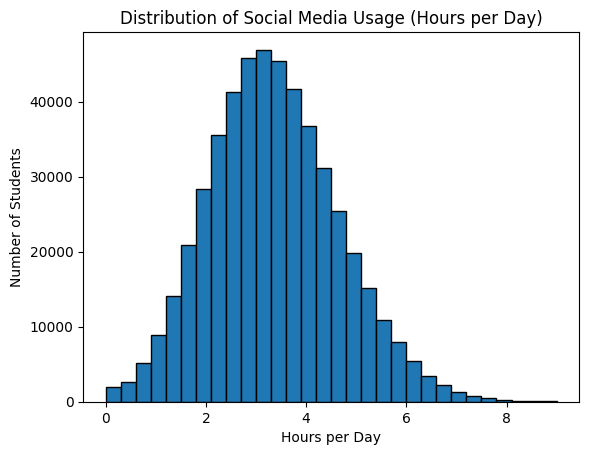

In [9]:
plt.hist(data['social_media_hours'], bins= 30, edgecolor= 'black');
plt.xlabel('Hours')
plt.title("Distribution of Social Media Usage (Hours per Day)")
plt.xlabel("Hours per Day")
plt.ylabel("Number of Students")

In [10]:
float_columns = data.select_dtypes(include= 'float32').columns.tolist()

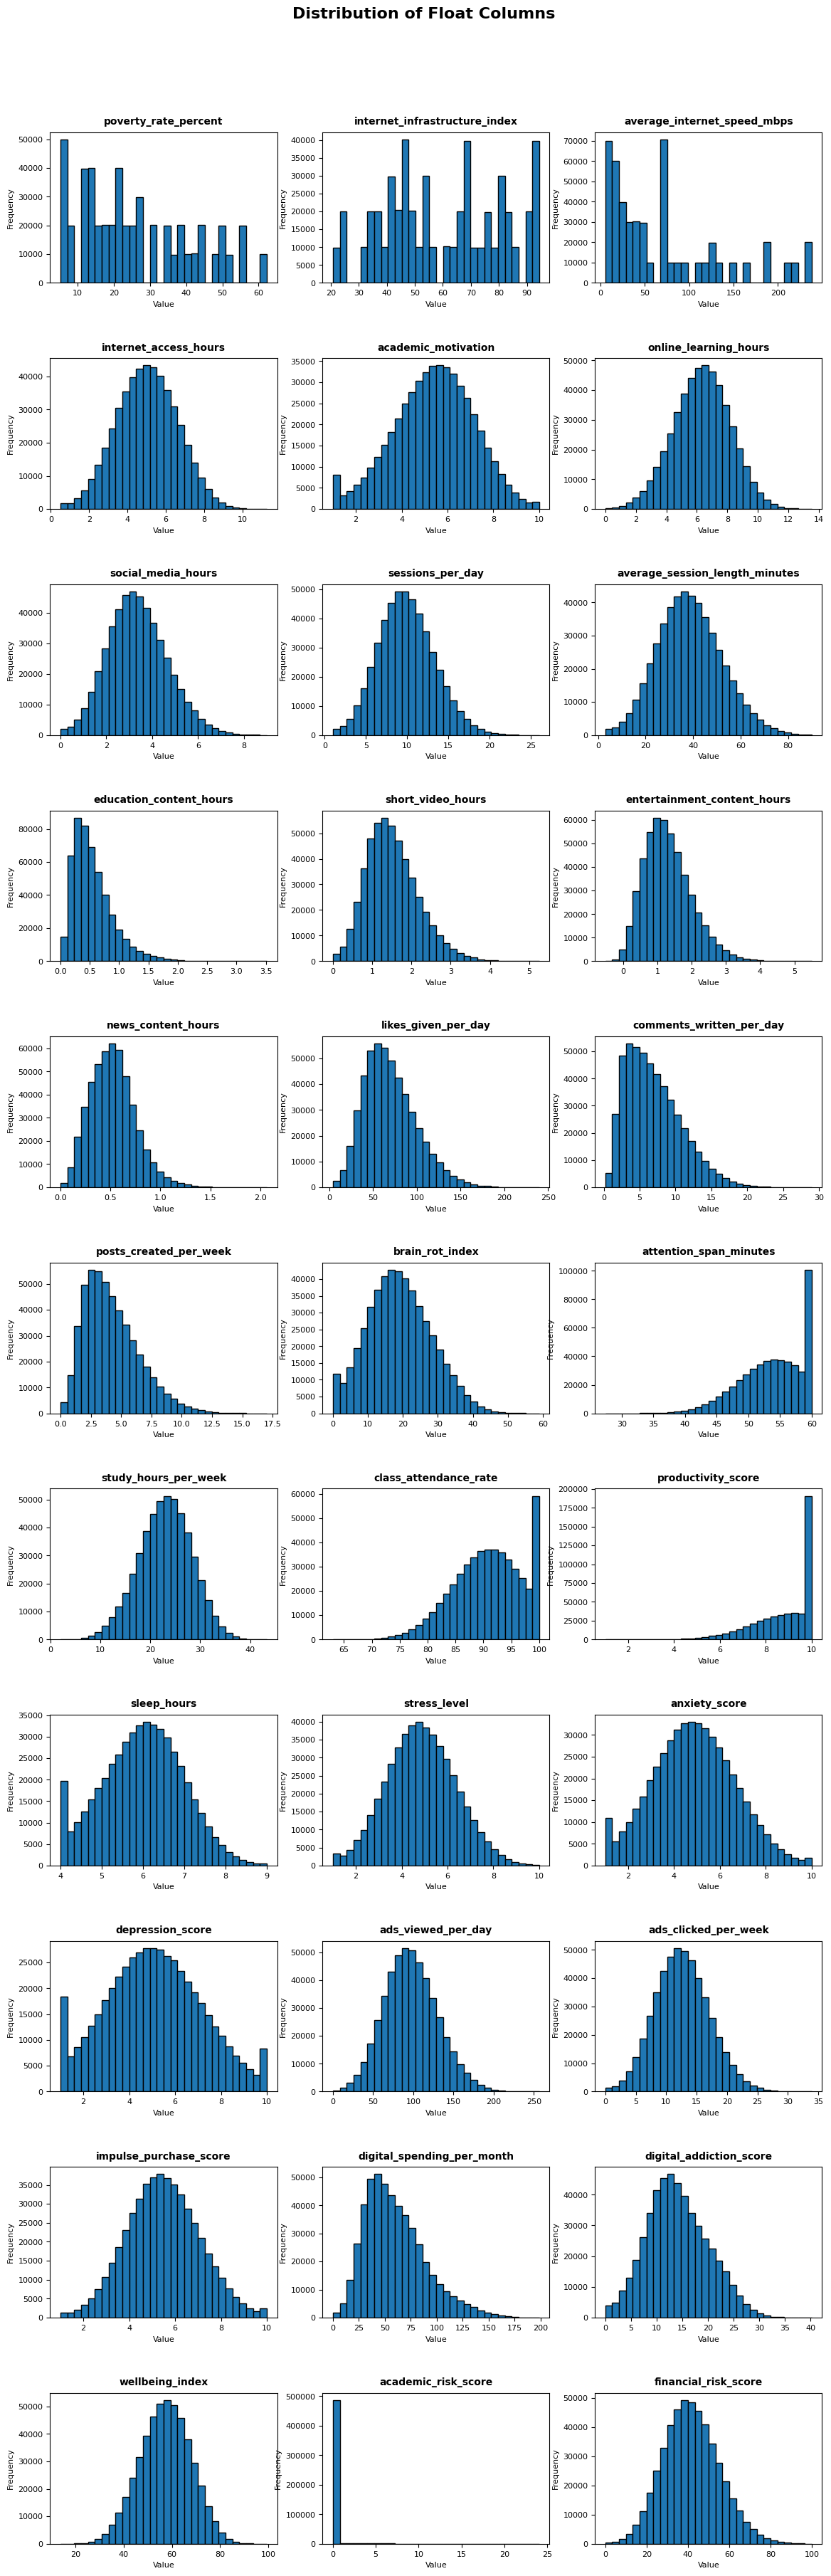

In [11]:
num_cols = 3 
num_rows = int(len(float_columns) / num_cols)

fig, ax = plt.subplots(num_rows, num_cols, figsize=(14, num_rows * 4))
fig.suptitle('Distribution of Float Columns', fontsize=16, fontweight='bold', y=0.92);
fig.subplots_adjust(hspace= 0.5)
for i in range(len(float_columns)):
    row = i // num_cols
    col = i % num_cols

    ax[row,col].hist(data[float_columns[i]], bins= 30, edgecolor= 'black');
    ax[row,col].set_title(f'{float_columns[i]}',fontweight= 'bold',fontsize= 10, pad= 8);
    ax[row,col].set_xlabel('Value', fontsize=8)
    ax[row,col].set_ylabel('Frequency', fontsize=8)
    ax[row,col].tick_params(labelsize=8)

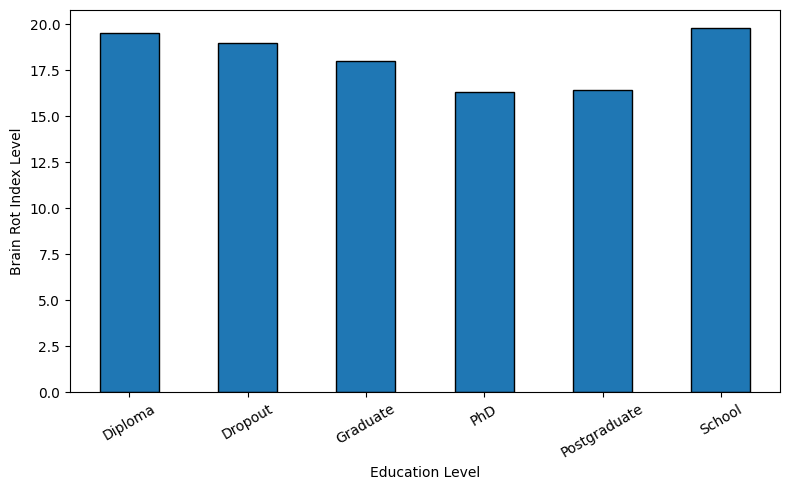

In [12]:
mean = data.groupby('education_level',observed= True, dropna= False)['brain_rot_index'].mean()
mean.plot(kind= 'bar', edgecolor= 'black', figsize= (8,5));
plt.xticks(rotation= 30);
plt.xlabel('Education Level');
plt.ylabel('Brain Rot Index Level');
plt.tight_layout();

In [13]:
data['social_media_usage'] = pd.cut(data['social_media_hours'],
    bins= [-0.01,3,5,12],
    labels= ['Low','Mid','High'])

data[['social_media_usage','anxiety_score','depression_score']]

,social_media_usage,anxiety_score,depression_score
student_id,,,
1,Low,3.192920,1.409102
2,High,8.064935,7.695220
3,Low,1.719159,1.000000
4,Low,4.860839,1.755233
5,High,6.025506,3.678578
...,...,...,...
499996,High,5.472848,6.336480
499997,Mid,5.065197,4.785137
499998,Mid,4.556139,2.587835


### Education Impact Of Social Media On Students 

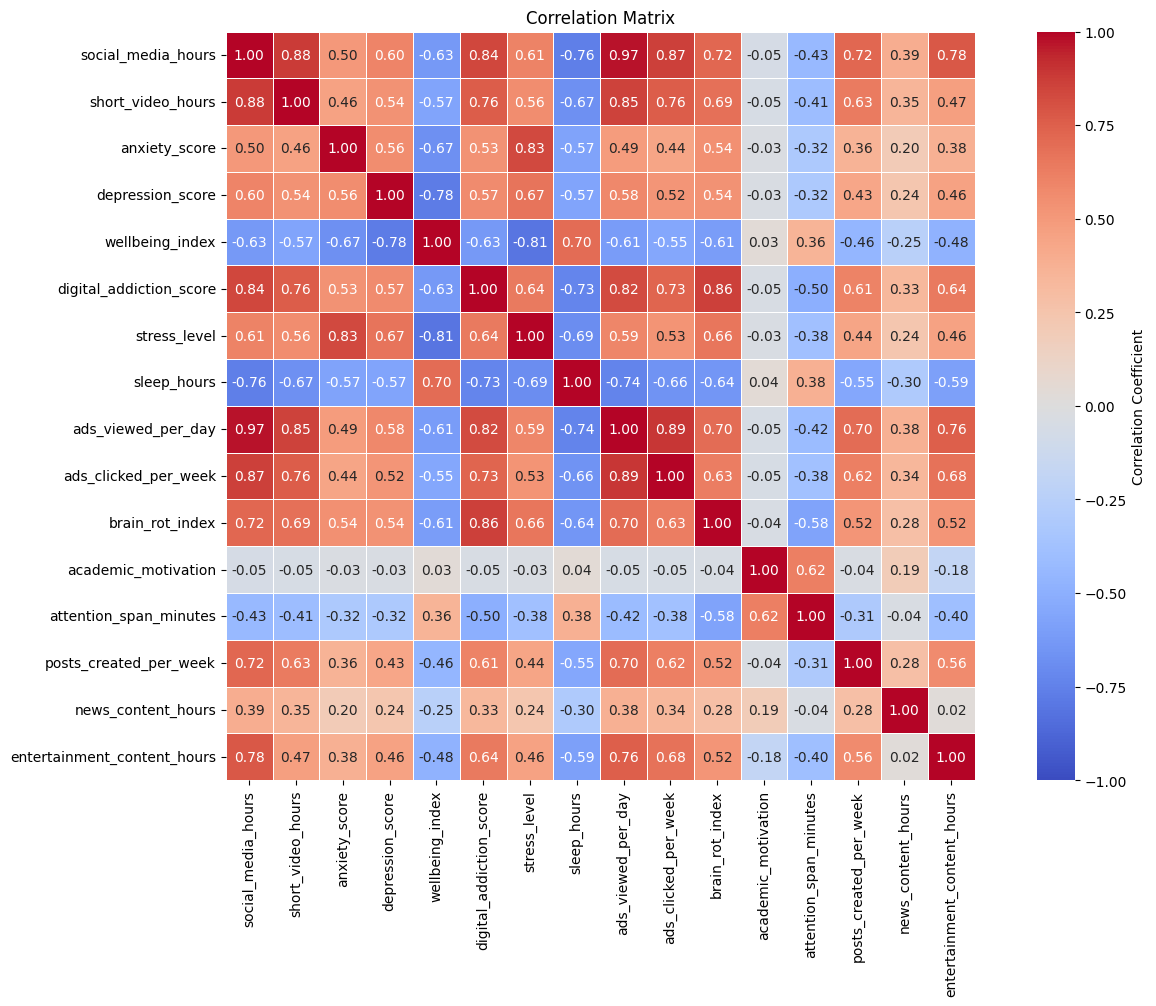

In [14]:
corr_table = data[['social_media_hours',
                'short_video_hours',
                'anxiety_score',
                'depression_score',
                'wellbeing_index',
                'digital_addiction_score',
                'stress_level',
                'sleep_hours',
                'ads_viewed_per_day',
                'ads_clicked_per_week',
                'brain_rot_index',
                'academic_motivation',
                'attention_span_minutes',
                'posts_created_per_week',
                'news_content_hours',
                'entertainment_content_hours']].corr()

plt.figure(figsize=(14, 10));
sns.heatmap(corr_table, annot=True,
    fmt='.2f',cmap='coolwarm',center=0,
    square=True,linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'},vmin=-1,vmax=1,);
plt.tight_layout()
plt.title('Correlation Matrix');

In [15]:
group_social_media_usage = data.groupby('social_media_usage', observed= True)[[
    'short_video_hours',
                'anxiety_score',
                'depression_score',
                'wellbeing_index',
                'digital_addiction_score',
                'stress_level',
                'sleep_hours',
                'ads_viewed_per_day',
                'ads_clicked_per_week',
                'brain_rot_index',
                'academic_motivation',
                'attention_span_minutes',
                'posts_created_per_week',
                'entertainment_content_hours',
                'productivity_score']].median()
group_social_media_usage

,short_video_hours,anxiety_score,depression_score,wellbeing_index,digital_addiction_score,stress_level,sleep_hours,ads_viewed_per_day,ads_clicked_per_week,brain_rot_index,academic_motivation,attention_span_minutes,posts_created_per_week,entertainment_content_hours,productivity_score
social_media_usage,,,,,,,,,,,,,,,
Low,0.964233,4.024098,3.889859,63.503597,9.666486,4.018038,6.665805,69.244423,9.148847,13.123620,5.561090,56.437794,2.561379,0.798091,9.847299
Mid,1.703294,5.192289,5.559448,54.700562,15.714990,5.185883,5.707210,108.500572,14.103663,21.208412,5.425651,53.311924,4.733500,1.485370,8.909739
High,2.545578,6.467782,7.382829,45.244583,22.901997,6.459993,4.619656,153.013504,19.538313,30.702400,5.219204,49.599735,7.088535,2.307703,7.780478


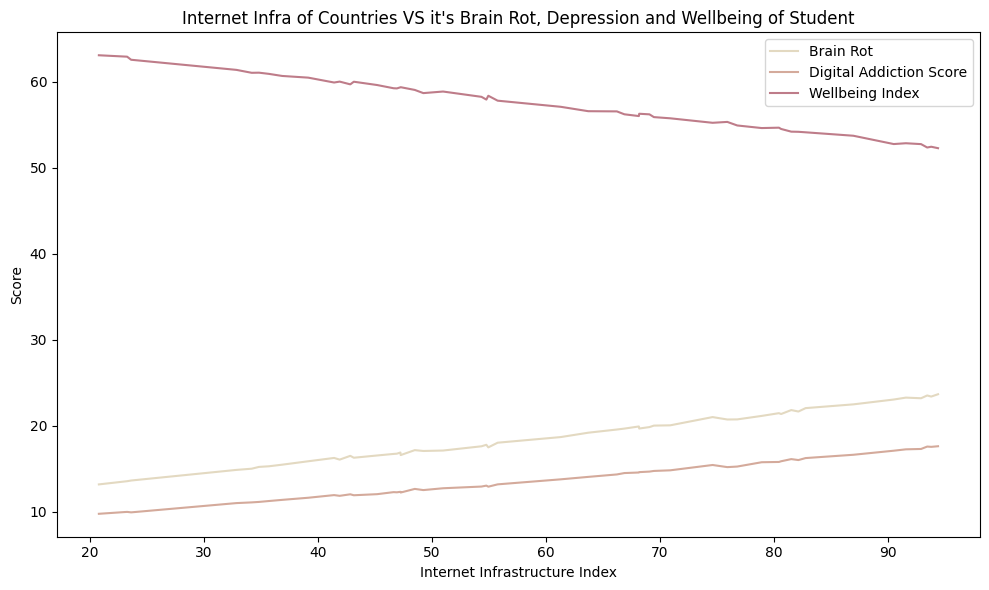

In [16]:

country_corr = data.groupby('internet_infrastructure_index', observed= True)[['short_video_hours',
                'anxiety_score',
                'depression_score',
                'wellbeing_index',
                'financial_risk_score',
                'digital_addiction_score',
                'stress_level',
                'sleep_hours',
                'ads_viewed_per_day',
                'ads_clicked_per_week',
                'brain_rot_index',
                'academic_motivation',
                'attention_span_minutes',
                'posts_created_per_week',
                'news_content_hours',
                'productivity_score',
                'education_content_hours',
                'online_learning_hours']].median().reset_index()

plt.figure(figsize= (10,6))
sns.set_palette("ch:s=-.2,r=.6")
sns.lineplot(country_corr, x= 'internet_infrastructure_index', y='brain_rot_index', label= 'Brain Rot',)
sns.lineplot(country_corr, x= 'internet_infrastructure_index', y='digital_addiction_score', label= 'Digital Addiction Score')
sns.lineplot(country_corr, x= 'internet_infrastructure_index', y='wellbeing_index', label= 'Wellbeing Index')
plt.xlabel('Internet Infrastructure Index');
plt.ylabel('Score');
plt.title('Internet Infra of Countries VS it\'s Brain Rot, Depression and Wellbeing of Student');
plt.tight_layout()
plt.legend(bbox_to_anchor=(1, 1));

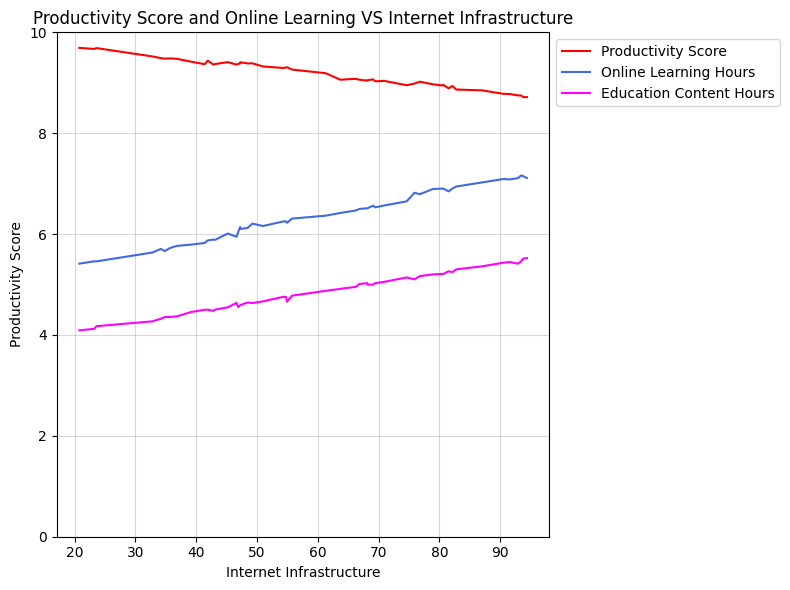

In [17]:
plt.figure(figsize= (8,6));
sns.lineplot(country_corr, x= 'internet_infrastructure_index', y='productivity_score', label= 'Productivity Score', color= 'Red')
sns.lineplot(country_corr, x= 'internet_infrastructure_index', y='online_learning_hours', label= 'Online Learning Hours', color= 'royalblue')
sns.lineplot(country_corr, x= 'internet_infrastructure_index', y='anxiety_score', label= 'Education Content Hours', color= 'magenta')
plt.title('Productivity Score and Online Learning VS Internet Infrastructure');
plt.xlabel('Internet Infrastructure');
plt.ylabel('Productivity Score')
plt.ylim(0,10)
plt.legend(bbox_to_anchor= (1,1));
plt.grid(True, alpha= 0.5);
plt.tight_layout();

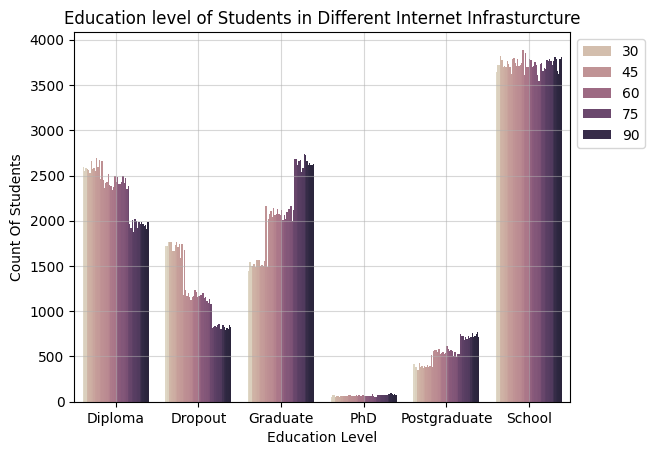

In [18]:
sns.countplot(data= data, x= 'education_level', hue= 'internet_infrastructure_index', palette= 'ch:s=-.2,r=.6')
plt.legend(bbox_to_anchor= (1,1));
plt.title('Education level of Students in Different Internet Infrasturcture');
plt.xlabel('Education Level');
plt.ylabel('Count Of Students');
plt.grid(True, alpha=0.5);

- Above Chart A (Productivity Score and Online Learning VS Internet Infrastructure) show that even though overall productivity of students drop marginally but, students online learning hours, increase.


- In Chart B (Education level of Students in Different Internet Infrasturcture), show number of students in school are almost similar regardless of internet infrastructre, but a big difference start to emerge as soon as we focus on higher education level, or drop out rate.
    - lower internet infrastructure countries have high drop out and lower Graduate or PostGraduate students, while better internet infrastructre countries have higher students count.

/home/Dadonko/Downloads/Coding/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/Dadonko/Downloads/Coding/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


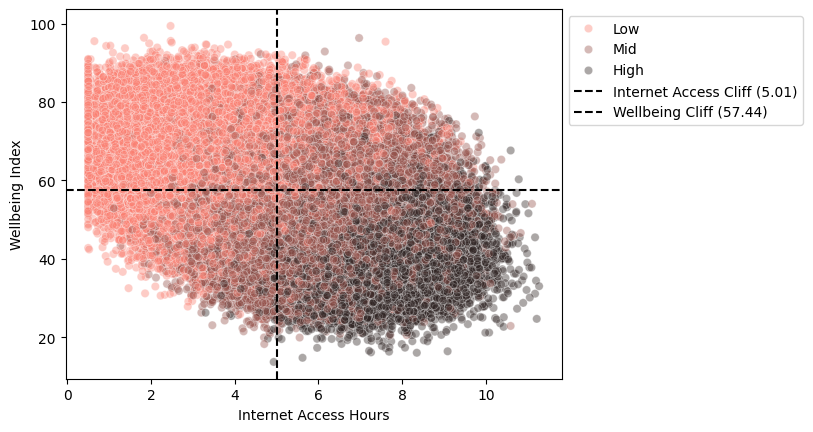

In [27]:
wellbeing_cliff = data[['wellbeing_index','internet_access_hours', 'social_media_usage']]

internet_access_cliff = wellbeing_cliff['internet_access_hours'].median()
wellbeing_index_cliff = wellbeing_cliff['wellbeing_index'].median()

sns.scatterplot(
    data= wellbeing_cliff,
    y= 'wellbeing_index',
    x= 'internet_access_hours',
    hue= 'social_media_usage',
    palette= 'dark:salmon_r',
    alpha= 0.4);

plt.axvline(
    x=internet_access_cliff,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Internet Access Cliff ({internet_access_cliff:.2f})')

plt.axhline(
    y=wellbeing_index_cliff,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Wellbeing Cliff ({wellbeing_index_cliff:.2f})')

plt.legend(bbox_to_anchor= (1,1));
plt.xlabel('Internet Access Hours');
plt.ylabel('Wellbeing Index');

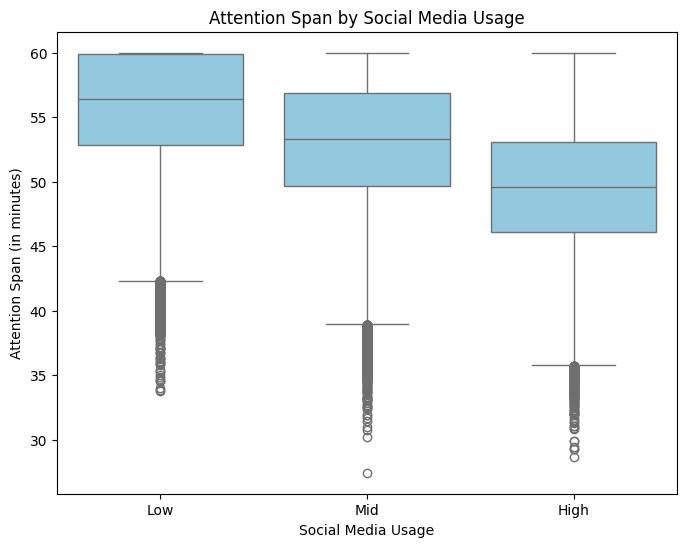

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x="social_media_usage",
    y="attention_span_minutes",
    data=data, color= 'skyblue'
)
plt.title("Attention Span by Social Media Usage");
plt.xlabel('Social Media Usage');
plt.ylabel('Attention Span (in minutes)');

Text(0.5, 1.0, 'Multi-Factor Academic Risk Profiling')

/home/Dadonko/Downloads/Coding/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


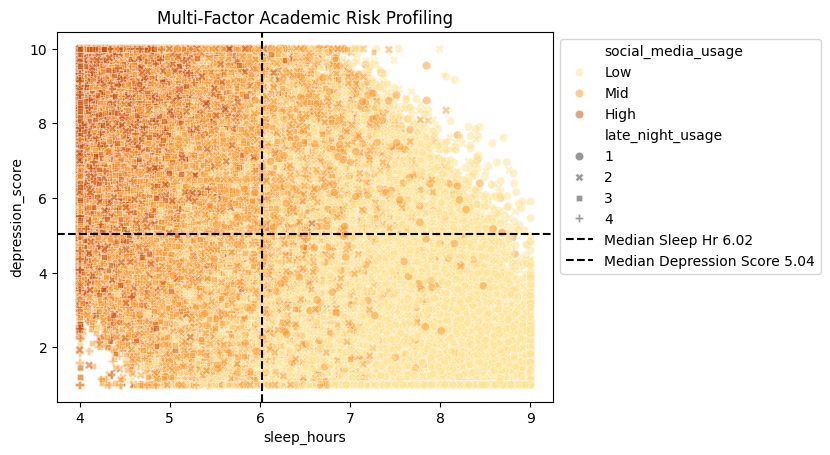

In [46]:
median_sleep_hr = data['sleep_hours'].median()
median_depression_score = data['depression_score'].median()

sns.scatterplot(
    data= data,
    x= 'sleep_hours',
    y= 'depression_score',
    hue= 'social_media_usage',
    style= 'late_night_usage',
    palette= 'YlOrBr',
    alpha= 0.5,
);

plt.axvline(x= median_sleep_hr, linestyle= '--', linewidth= 1.5, label= f'Median Sleep Hr {median_sleep_hr:.2f}', color= 'black');
plt.axhline(y= median_depression_score, linestyle= '--', linewidth= 1.5, label= f'Median Depression Score {median_depression_score:.2f}', color= 'black');
plt.legend(bbox_to_anchor= (1,1));
plt.title("Multi-Factor Academic Risk Profiling");

##### Insight:
- It can be seen that students with high Social Media Usage, are not getting enought sleep.
- late night usage is ordinal data type. 
- Also less sleep show students with high depression score.
- Hence, A good sleep (7-8 hours), is better for mental health.

/home/Dadonko/Downloads/Coding/.venv/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/Dadonko/Downloads/Coding/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


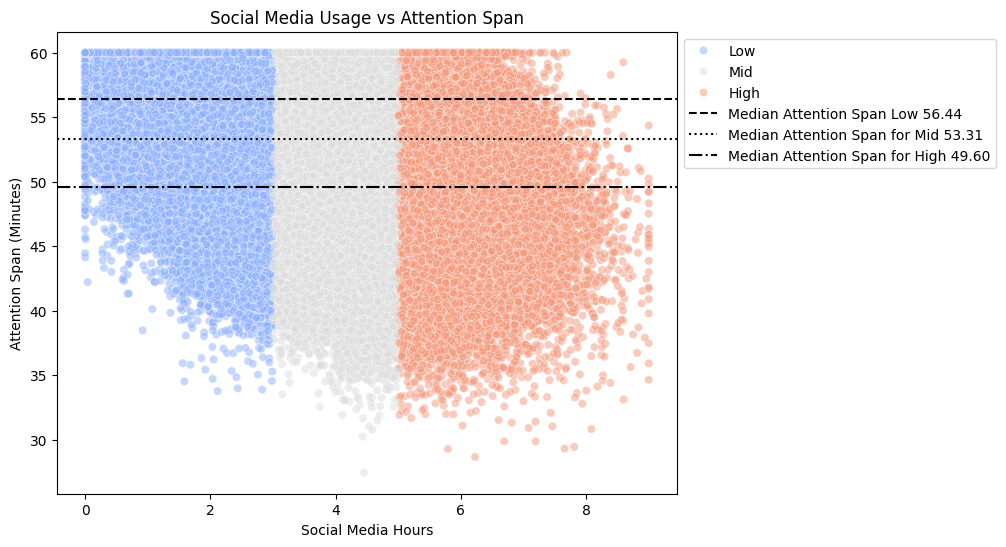

In [28]:
median_high = data[(data['social_media_usage'] == 'High')]['attention_span_minutes'].median()
median_mid = data[(data['social_media_usage'] == 'Mid')]['attention_span_minutes'].median()
median_low = data[(data['social_media_usage'] == 'Low')]['attention_span_minutes'].median()


plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data,
    x= 'social_media_hours',
    y= 'attention_span_minutes',
    hue= 'social_media_usage',
    alpha=0.5,
    palette= 'coolwarm'
);
plt.axhline(y=median_low, linestyle = '--', linewidth= 1.5, color= 'black', label= f'Median Attention Span Low {median_low:.2f}')
plt.axhline(y=median_mid, linestyle = 'dotted', linewidth= 1.5, color= 'black', label= f'Median Attention Span for Mid {median_mid:.2f}')
plt.axhline(y=median_high, linestyle = 'dashdot', linewidth= 1.5, color= 'black', label= f'Median Attention Span for High {median_high:.2f}')
plt.legend(bbox_to_anchor= (1,1));
plt.title("Social Media Usage vs Attention Span");
plt.xlabel("Social Media Hours");
plt.ylabel("Attention Span (Minutes)");

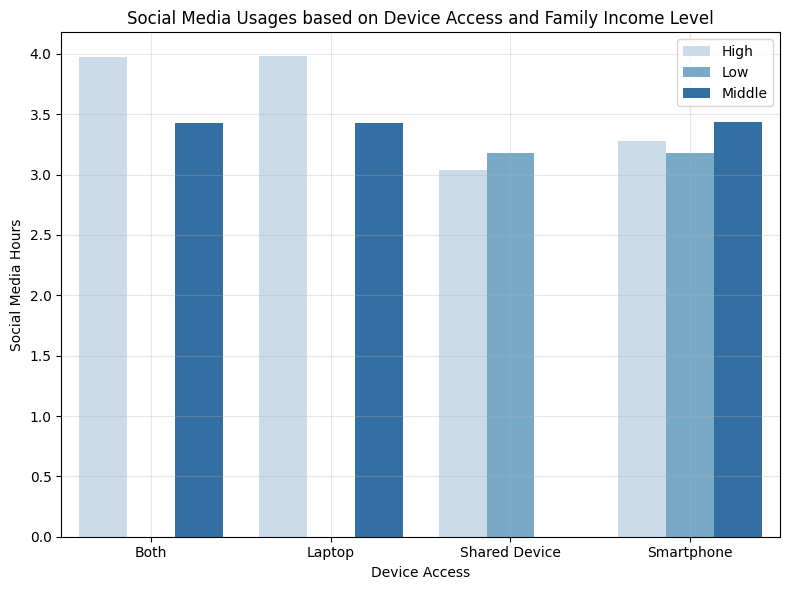

In [29]:
social_media_access = data.groupby(['device_access', 'family_income_level'], observed= True)[['social_media_hours']].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data= social_media_access,x= 'device_access',y= 'social_media_hours', hue= 'family_income_level', palette= 'Blues');
plt.legend(bbox_to_anchor= (1,1));
plt.xlabel('Device Access');
plt.ylabel('Social Media Hours');
plt.title('Social Media Usages based on Device Access and Family Income Level');
plt.tight_layout()
plt.grid(True, alpha= 0.3)

- In Low Income Families, only way of accessing social media is only thorugh smartphones of shared device

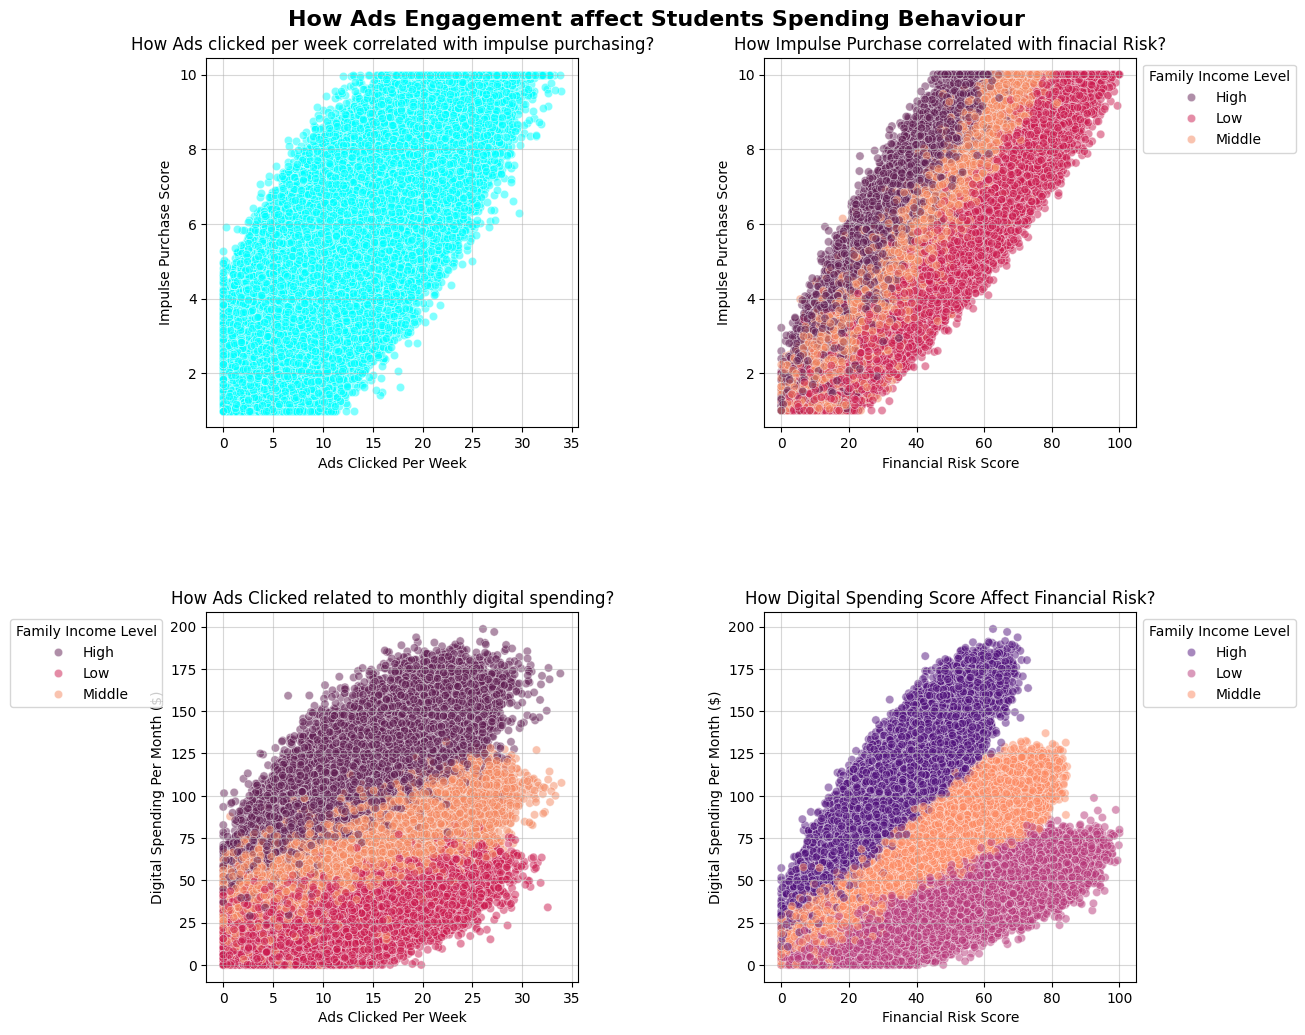

In [24]:
spending_data = data[['family_income_level','ads_viewed_per_day','digital_spending_per_month', 'ads_clicked_per_week', 'impulse_purchase_score','financial_risk_score']]

fig, ax = plt.subplots(2,2, figsize= (12,12))
fig.subplots_adjust(hspace= 0.5, wspace= 0.5)
fig.suptitle('How Ads Engagement affect Students Spending Behaviour', fontsize=16, fontweight='bold', y=0.92);

sns.scatterplot(
    data= spending_data,
    y= 'impulse_purchase_score',
    x= 'financial_risk_score',
    palette= 'rocket',
    hue= 'family_income_level',
    ax= ax[0,1],color= 'blue', alpha= 0.5);
ax[0,1].grid(True, alpha= 0.5)
ax[0,1].legend(loc= 'upper left', bbox_to_anchor= (1,1), title= 'Family Income Level')
ax[0,1].set_xlabel('Financial Risk Score');
ax[0,1].set_ylabel('Impulse Purchase Score');
ax[0,1].set_title('How Impulse Purchase correlated with finacial Risk?');


sns.scatterplot(
    data=spending_data,
    x= 'ads_clicked_per_week',
    y= 'impulse_purchase_score',
    color= 'cyan',
    ax= ax[0,0], alpha= 0.5);
ax[0,0].grid(True, alpha= 0.5)
ax[0,0].set_xlabel('Ads Clicked Per Week');
ax[0,0].set_ylabel('Impulse Purchase Score');
ax[0,0].set_title('How Ads clicked per week correlated with impulse purchasing?');


sns.scatterplot(
    data= spending_data,
    y= 'digital_spending_per_month',
    x= 'ads_clicked_per_week',
    palette= 'rocket',
    hue= 'family_income_level',
    ax= ax[1,0], alpha= 0.5);
ax[1,0].legend(loc= 'upper right', bbox_to_anchor= (-0.1,1), title= 'Family Income Level');
ax[1,0].grid(True, alpha= 0.5)
ax[1,0].set_ylabel('Digital Spending Per Month ($)');
ax[1,0].set_xlabel('Ads Clicked Per Week');
ax[1,0].set_title('How Ads Clicked related to monthly digital spending?');


sns.scatterplot(
    data= spending_data,
    x= 'financial_risk_score',
    y= 'digital_spending_per_month',
    palette= 'magma',
    hue= 'family_income_level',
    ax= ax[1,1], alpha= 0.5);
ax[1,1].legend(loc= 'upper left',bbox_to_anchor= (1,1), title= 'Family Income Level');
ax[1,1].grid(True, alpha= 0.5);
ax[1,1].set_ylabel('Digital Spending Per Month ($)');
ax[1,1].set_xlabel('Financial Risk Score');
ax[1,1].set_title('How Digital Spending Score Affect Financial Risk?');

- Impulse Purchase behavior is postivily correlated with Ads clicked per week, digital spending regardless of Family Income level.
- All these factors increase finacial risk of students.

In [44]:
data['internet_usage'] = pd.qcut(data['internet_access_hours'], q= 3, labels= ['Low', 'Mid', 'High'])

low_internet = data[(data['internet_usage'] == 'Low')]['wellbeing_index']
mid_internet = data[(data['internet_usage'] == 'Mid')]['wellbeing_index']
high_internet = data[(data['internet_usage'] == 'High' )]['wellbeing_index']

f_stats, p_val = sp_stat.f_oneway(low_internet, mid_internet, high_internet)
if p_val < 0.05:
    print('We reject Null Hypothesis, There is a Significant difference')
else:
    print('We Fail to reject null hypothese')

print(f'ANOVA f-statistic: {f_stats}, p-value: {p_val:.2e}')

We reject Null Hypothesis, There is a Significant difference
ANOVA f-statistic: 45424.39453125, p-value: 0.00e+00


In [35]:
low = data[(data['social_media_usage'] == 'Low')]['digital_addiction_score']
mid = data[(data['social_media_usage'] == 'Mid')]['digital_addiction_score']
high = data[(data['social_media_usage'] == 'High')]['digital_addiction_score']


f_stats, p_val = sp_stat.f_oneway(low, mid, high)
if p_val < 0.05:
    print('We reject Null Hypothesis, There is a Significant difference')
else:
    print('We Fail to reject null hypothese')

print(f'ANOVA f-statistic: {f_stats}, p-value: {p_val:.2e}')

We reject Null Hypothesis, There is a Significant difference
ANOVA f-statistic: 290914.8125, p-value: 0.00e+00


In [45]:
data['ads_clicked'] = pd.qcut(data['ads_clicked_per_week'], q= 3, labels= ['Low', 'Mid', 'High'])

low_financial = data[(data['ads_clicked'] == 'Low')]['financial_risk_score']
mid_financial = data[(data['ads_clicked'] == 'Mid')]['financial_risk_score']
high_financial = data[(data['ads_clicked'] == 'High')]['financial_risk_score']


f_stats, p_val = sp_stat.f_oneway(low_financial, mid_financial, high_financial)
if p_val < 0.05:
    print('We reject Null Hypothesis, There is a Significant difference')
else:
    print('We Fail to reject null hypothese')

print(f'ANOVA f-statistic: {f_stats}, p-value: {p_val:.2e}')

We reject Null Hypothesis, There is a Significant difference
ANOVA f-statistic: 93567.1796875, p-value: 0.00e+00
